In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

# Visualization (optional)
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
# Load Dataset

df = pd.read_csv("Churn_Modelling.csv")

# View data
print(df.head())
print(df.info())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [3]:
# Drop Unnecessary Columns

df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [4]:
# Encode Categorical Variables

# Convert Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-hot encode Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [5]:
# Define Features and Target

X = df.drop('Exited', axis=1)
y = df['Exited']

In [6]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Train Logistic Regression Model

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [9]:
# Feature Coefficients (Log-Odds Interpretation)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Log-Odds)': model.coef_[0]
})

print(coefficients.sort_values(by='Coefficient (Log-Odds)', ascending=False))

              Feature  Coefficient (Log-Odds)
2                 Age                0.754217
9   Geography_Germany                0.337190
4             Balance                0.161139
10    Geography_Spain                0.038960
8     EstimatedSalary                0.015744
6           HasCrCard               -0.010236
3              Tenure               -0.042637
5       NumOfProducts               -0.060278
0         CreditScore               -0.067683
1              Gender               -0.264718
7      IsActiveMember               -0.533432


In [10]:
# Predictions

y_pred = model.predict(X_test)

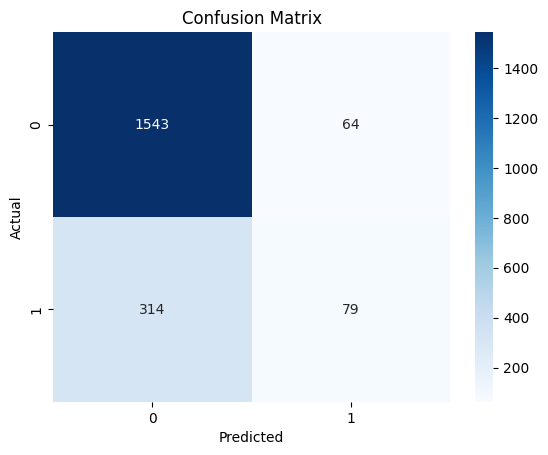

In [11]:
# Model Evaluation

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
# Classification Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.811

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

